<a href="https://colab.research.google.com/github/zzzer0-wav/myDTA_2026/blob/main/classmade/PANDAS_cheat_sheet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐼 Pandas + 📊 Matplotlib: Аналіз даних з нуля

Цей блокнот побудований за принципом **«дізнався — одразу побачив»**:
кожна нова техніка pandas одразу підкріплюється графіком.

**Matplotlib** тут — як фотоапарат: ти не вивчаєш його окремо,
ти просто робиш знімки своїх даних у потрібний момент.

---
### Як працювати з блокнотом
- ▶️ **Shift+Enter** — запустити клітинку і перейти до наступної
- 📖 Текстові клітинки — теорія та пояснення
- 💻 Сірі клітинки — код, який треба запускати
- 🎯 **Завдання** — виконуй сам, підказка нижче
- 💡 Клітинки з підказками — запускай лише якщо справді застряг
---

## Розділ 0 — Підготовка: імпорт бібліотек

Перед роботою треба «підключити» бібліотеки.

```
pandas     → працюємо з таблицями
matplotlib → малюємо графіки
numpy      → числові операції
```

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print(f'   pandas     {pd.__version__}')
print(f'   numpy      {np.__version__}')
print(f'   matplotlib {plt.matplotlib.__version__}')

   pandas     2.2.2
   numpy      2.0.2
   matplotlib 3.10.0


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

---
## Розділ 1 — DataFrame: таблиця даних

**DataFrame** — це таблиця, як у Excel. Рядки — це записи, стовпці — це характеристики.

Уяви, що ти отримав таблицю продажів маленького кафе за тиждень.
Давай завантажимо її вручну й одразу подивимось на дані.

In [15]:
# Створюємо DataFrame зі словника Python
# Ключі словника → назви стовпців
# Списки → значення в стовпцях

cafe = pd.DataFrame({
    'День':        ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Нд'],
    'Відвідувачі': [87, 64, 95, 78, 142, 198, 173],
    'Виручка':     [4350, 3200, 4750, 3900, 7100, 9900, 8650],
    'Погода':      ['Ясно', 'Дощ', 'Хмарно', 'Ясно', 'Ясно', 'Ясно', 'Хмарно']
})

# Просто написати назву змінної — pandas покаже гарну таблицю
cafe

,День,Відвідувачі,Виручка,Погода
0,Пн,87,4350,Ясно
1,Вт,64,3200,Дощ
2,Ср,95,4750,Хмарно
3,Чт,78,3900,Ясно
4,Пт,142,7100,Ясно
5,Сб,198,9900,Ясно
6,Нд,173,8650,Хмарно


Зверни увагу: pandas автоматично додав **індекс** (0, 1, 2...) — номер рядка.

Тепер запитаємо pandas: «що це взагалі за дані?»

In [16]:
print('Розмір таблиці (рядки, стовпці):', cafe.shape)
print()
print('Типи даних у кожному стовпці:')
print(cafe.dtypes)

Розмір таблиці (рядки, стовпці): (7, 4)

Типи даних у кожному стовпці:
День           object
Відвідувачі     int64
Виручка         int64
Погода         object
dtype: object


In [17]:
# .describe() — миттєва статистика по числових стовпцях
cafe.describe().round(1)

,Відвідувачі,Виручка
count,7.0,7.0
mean,119.6,5978.6
std,51.6,2581.2
min,64.0,3200.0
25%,82.5,4125.0
50%,95.0,4750.0
75%,157.5,7875.0
max,198.0,9900.0


### 📊 Перший графік — одразу після першої таблиці

Pandas має вбудований метод `.plot()` — він викликає matplotlib за тебе.
Формула проста:
```python
df.plot(x='стовпець_для_осі_X', y='стовпець_для_осі_Y', kind='тип_графіка')
plt.show()
```
Типи: `line`, `bar`, `barh`, `hist`, `scatter`, `pie`

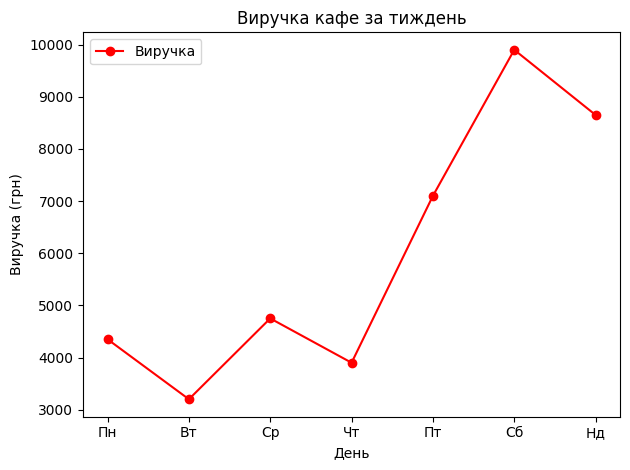

In [18]:
# Лінійний графік виручки по днях
cafe.plot(
    x='День', y='Виручка',
    kind='line',
    marker='o',
    color='red',
    title='Виручка кафе за тиждень',
    # xlabel=
    ylabel='Виручка (грн)',
    legend=True
)
plt.tight_layout()
plt.show()

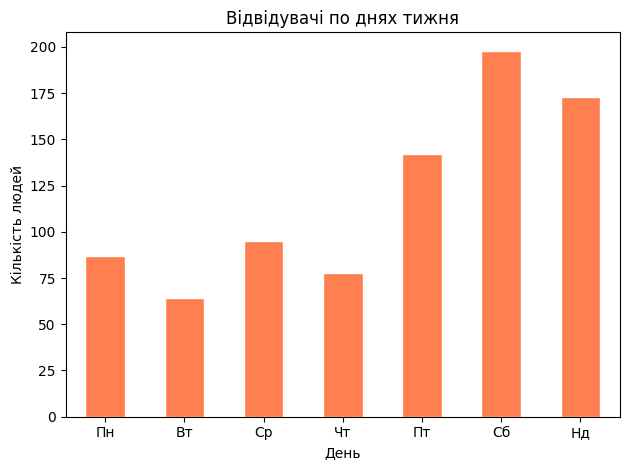

In [19]:
# Стовпчаста діаграма — краща для порівняння по категоріях
cafe.plot(
    x='День', y='Відвідувачі',
    kind='bar',
    color='coral',
    edgecolor='white',
    title='Відвідувачі по днях тижня',
    ylabel='Кількість людей',
    legend=False,
    rot=0
)
plt.tight_layout()
plt.show()

### 🎯 Завдання 1.1

Створи DataFrame із даними про температуру у 5 містах:

| Місто | Температура | Вологість_% | Опади_мм |
|-------|-------------|-------------|----------|
| Київ | 18 | 72 | 5 |
| Харків | 21 | 65 | 0 |
| Одеса | 24 | 80 | 0 |
| Львів | 15 | 78 | 12 |
| Дніпро | 22 | 60 | 0 |

Потім:
1. Виведи таблицю та `.describe()`
2. Побудуй **горизонтальний** bar chart (`kind='barh'`) температури по містах

In [20]:
# Твій код тут:
weather = pd.DataFrame({
    'Місто':       ['Київ','Харків','Одеса','Львів','Дніпро'],
    'Температура': [18, 21, 24, 15, 22],
    'Вологість_%': [72, 65, 80, 78, 60],
    'Опади_мм':    [5, 0, 0, 12, 0]
})

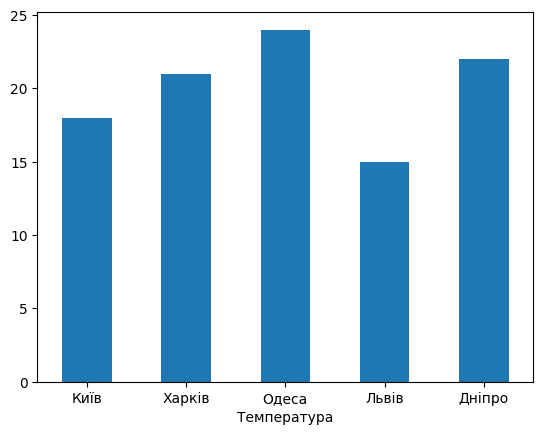

In [21]:
weather.plot(
    x='Місто',
    y='Температура',
    kind='bar',
    legend=False,
    xlabel='Температура',
    rot=0
)

plt.show()

In [22]:
# 💡 Підказка:
print("""
weather = pd.DataFrame({
    'Місто':       ['Київ','Харків','Одеса','Львів','Дніпро'],
    'Температура': [18, 21, 24, 15, 22],
    'Вологість_%': [72, 65, 80, 78, 60],
    'Опади_мм':    [5, 0, 0, 12, 0]
})
print(weather)
print(weather.describe().round(1))

weather.plot(x='Місто', y='Температура', kind='barh',
             color='tomato', title='Температура по містах',
             xlabel='°C', legend=False)
plt.tight_layout()
plt.show()
""")


weather = pd.DataFrame({
    'Місто':       ['Київ','Харків','Одеса','Львів','Дніпро'],
    'Температура': [18, 21, 24, 15, 22],
    'Вологість_%': [72, 65, 80, 78, 60],
    'Опади_мм':    [5, 0, 0, 12, 0]
})
print(weather)
print(weather.describe().round(1))

weather.plot(x='Місто', y='Температура', kind='barh',
             color='tomato', title='Температура по містах',
             xlabel='°C', legend=False)
plt.tight_layout()
plt.show()



---
## Розділ 2 — Вибірка даних: стовпці та рядки

Більшість часу аналітик працює не з усією таблицею, а з її частинами.
Давай навчимось «витягувати» потрібне.

Для цього розділу завантажимо більший датасет — дані інтернет-магазину.

In [23]:
# Генеруємо реалістичний датасет замовлень
np.random.seed(42)
n = 120

shop = pd.DataFrame({
    'Замовлення_ID': range(1001, 1001 + n),
    'Клієнт':    np.random.choice(['Олена К.','Максим Р.','Аня С.','Богдан В.',
                                    'Катя М.','Ігор Л.','Софія Д.','Тарас Н.'], n),
    'Категорія': np.random.choice(['Електроніка','Одяг','Книги','Спорт','Дім'], n,
                                   p=[0.25, 0.30, 0.15, 0.15, 0.15]),
    'Місто':     np.random.choice(['Київ','Харків','Одеса','Львів','Дніпро'], n,
                                   p=[0.35, 0.20, 0.15, 0.20, 0.10]),
    'Сума':      (np.random.exponential(600, n) + 150).round(0).astype(int),
    'Кількість': np.random.randint(1, 6, n),
    'Доставка':  np.random.choice(['Нова Пошта','Укрпошта','Кур\'єр'], n,
                                   p=[0.55, 0.25, 0.20])
})

print(f'Розмір: {shop.shape[0]} замовлень, {shop.shape[1]} стовпців')
shop.head(6)

Розмір: 120 замовлень, 7 стовпців


,Замовлення_ID,Клієнт,Категорія,Місто,Сума,Кількість,Доставка
0,1001,Софія Д.,Одяг,Київ,182,1,Укрпошта
1,1002,Богдан В.,Одяг,Київ,605,5,Укрпошта
2,1003,Катя М.,Спорт,Дніпро,617,5,Нова Пошта
3,1004,Софія Д.,Одяг,Львів,759,2,Кур'єр
4,1005,Аня С.,Одяг,Київ,927,2,Кур'єр
5,1006,Тарас Н.,Одяг,Одеса,2384,2,Нова Пошта


### Вибір стовпців

In [24]:
# Один стовпець → Series (як список з індексом)
print('Тип одного стовпця:', type(shop['Сума']))
print()
print(shop['Сума'].head(5))

Тип одного стовпця: <class 'pandas.core.series.Series'>

0    182
1    605
2    617
3    759
4    927
Name: Сума, dtype: int64


In [25]:
# Кілька стовпців → DataFrame (подвійні дужки!)
shop[['Клієнт', 'Категорія', 'Сума']].head(6)

,Клієнт,Категорія,Сума
0,Софія Д.,Одяг,182
1,Богдан В.,Одяг,605
2,Катя М.,Спорт,617
3,Софія Д.,Одяг,759
4,Аня С.,Одяг,927
5,Тарас Н.,Одяг,2384


### Вибір рядків: `.iloc` та `.loc`

| Метод | Логіка | Приклад |
|-------|--------|---------|
| `.iloc[i]` | За **номером** рядка (як у списку) | `df.iloc[0]` — перший рядок |
| `.loc[i]`  | За **міткою** індексу | `df.loc[0]` — рядок з індексом 0 |

In [26]:
# .iloc — за позицією
print('Перший рядок (iloc[0]):')
print(shop.iloc[0])
print()
print('Рядки 2-4, стовпці 0-2:')
print(shop.iloc[2:5, 0:3])

Перший рядок (iloc[0]):
Замовлення_ID        1001
Клієнт           Софія Д.
Категорія            Одяг
Місто                Київ
Сума                  182
Кількість               1
Доставка         Укрпошта
Name: 0, dtype: object

Рядки 2-4, стовпці 0-2:
   Замовлення_ID    Клієнт Категорія
2           1003   Катя М.     Спорт
3           1004  Софія Д.      Одяг
4           1005    Аня С.      Одяг


### Фільтрація рядків — найважливіша операція!

Принцип: всередині `df[...]` пишемо **умову**, і pandas лишає лише рядки, де вона True.

In [27]:
# Замовлення на суму понад 1000 грн
big_orders = shop[shop['Сума'] > 1000]
print(f'Великих замовлень: {len(big_orders)} із {len(shop)}')
big_orders[['Замовлення_ID','Клієнт','Категорія','Сума']].head(5)

Великих замовлень: 27 із 120


,Замовлення_ID,Клієнт,Категорія,Сума
5,1006,Тарас Н.,Одяг,2384
8,1009,Софія Д.,Електроніка,1101
13,1014,Аня С.,Спорт,2122
14,1015,Тарас Н.,Спорт,1235
24,1025,Богдан В.,Одяг,2009


In [28]:
# Складні умови: & (і), | (або)
# ВАЖЛИВО: кожна умова в дужках!

# Електроніка з Києва
kyiv_electronics = shop[(shop['Місто'] == 'Київ') & (shop['Категорія'] == 'Електроніка')]
print(f'Електроніка з Києва: {len(kyiv_electronics)} замовлень')

# Дорогі замовлення або книги
premium_or_books = shop[(shop['Сума'] > 2000) | (shop['Категорія'] == 'Книги')]
print(f'Дорогі або книги:    {len(premium_or_books)} замовлень')

Електроніка з Києва: 6 замовлень
Дорогі або книги:    18 замовлень


In [29]:
# .isin() — перевірка входження у список значень
western = shop[shop['Місто'].isin(['Київ', 'Львів'])]
western
print(f'Київ або Львів: {len(western)} замовлень')

# .between() — діапазон
mid_range = shop[shop['Сума'].between(500, 1500)]
print(f'Сума 500-1500 грн: {len(mid_range)} замовлень')

Київ або Львів: 67 замовлень
Сума 500-1500 грн: 53 замовлень


### 📊 Гістограма — перший погляд на розподіл числових даних

Перш ніж аналізувати числа — подивись, **як вони розподілені**.

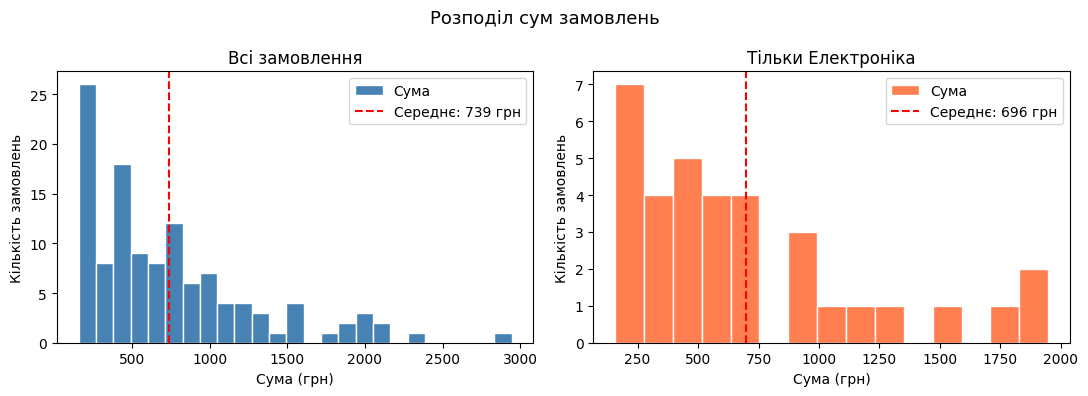

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Розподіл сум ВСІХ замовлень
shop['Сума'].plot.hist(ax=axes[0], bins=25, color='steelblue',
                       edgecolor='white', title='Всі замовлення')
axes[0].set_xlabel('Сума (грн)')
axes[0].set_ylabel('Кількість замовлень')
axes[0].axvline(shop['Сума'].mean(), color='red', linestyle='--',
                label=f"Середнє: {shop['Сума'].mean():.0f} грн")
axes[0].legend()

# Розподіл тільки по Електроніці
elec = shop[shop['Категорія'] == 'Електроніка']['Сума']
elec.plot.hist(ax=axes[1], bins=15, color='coral',
               edgecolor='white', title='Тільки Електроніка')
axes[1].set_xlabel('Сума (грн)')
axes[1].set_ylabel('Кількість замовлень')
axes[1].axvline(elec.mean(), color='red', linestyle='--',
                label=f'Середнє: {elec.mean():.0f} грн')
axes[1].legend()

plt.suptitle('Розподіл сум замовлень', fontsize=13)
plt.tight_layout()
plt.show()

### 🎯 Завдання 2.1

Використовуючи датасет `shop`:
1. Виведи всі замовлення з Харкова
2. Знайди замовлення, де кількість товарів >= 4 і сума < 500 грн
3. Побудуй гістограму сум замовлень **тільки для Харкова** (порівняй зі загальною)

In [31]:
# Твій код тут:


In [32]:
# 💡 Підказка:
print("""
# 1.
kharkiv = shop[shop['Місто'] == 'Харків']
print(kharkiv)

# 2.
odd = shop[(shop['Кількість'] >= 4) & (shop['Сума'] < 500)]
print(odd)

# 3.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
shop['Сума'].plot.hist(ax=axes[0], bins=20, color='steelblue',
                       edgecolor='white', title='Всі міста')
kharkiv['Сума'].plot.hist(ax=axes[1], bins=15, color='darkorange',
                          edgecolor='white', title='Тільки Харків')
plt.tight_layout()
plt.show()
""")


# 1.
kharkiv = shop[shop['Місто'] == 'Харків']
print(kharkiv)

# 2.
odd = shop[(shop['Кількість'] >= 4) & (shop['Сума'] < 500)]
print(odd)

# 3.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
shop['Сума'].plot.hist(ax=axes[0], bins=20, color='steelblue',
                       edgecolor='white', title='Всі міста')
kharkiv['Сума'].plot.hist(ax=axes[1], bins=15, color='darkorange',
                          edgecolor='white', title='Тільки Харків')
plt.tight_layout()
plt.show()



---
## Розділ 3 — Нові стовпці та трансформації

Сирі дані рідко містять все потрібне. Аналітик **створює нові характеристики** з існуючих.

In [33]:
s = shop.copy()

# 1. Простий обчислюваний стовпець
s['Ціна_за_одиницю'] = (s['Сума'] / s['Кількість']).round(0).astype(int)

# 2. Умовний стовпець через np.where (як IF в Excel)
# np.where(умова, якщо_True, якщо_False)
s['Знижка'] = np.where(s['Сума'] > 1000, (s['Сума'] * 0.95).round(0), s['Сума']).astype(int)

# 3. Кілька рівнів умов (вкладені np.where)
s['Сегмент'] = np.where(s['Сума'] >= 1500, 'Великий',
               np.where(s['Сума'] >= 600,  'Середній', 'Малий'))

s[['Замовлення_ID','Сума','Кількість','Ціна_за_одиницю','Сегмент', 'Знижка']].head(8)

,Замовлення_ID,Сума,Кількість,Ціна_за_одиницю,Сегмент,Знижка
0,1001,182,1,182,Малий,182
1,1002,605,5,121,Середній,605
2,1003,617,5,123,Середній,617
3,1004,759,2,380,Середній,759
4,1005,927,2,464,Середній,927
5,1006,2384,2,1192,Великий,2265
6,1007,586,5,117,Малий,586
7,1008,384,3,128,Малий,384


In [34]:
# pd.cut — автоматичний поділ на діапазони
s['Сума_група'] = pd.cut(
    s['Сума'],
    bins=[0, 300, 700, 1500, 99999],
    labels=['до 300', '300-700', '700-1500', '1500+']
)

print(s['Сума_група'].value_counts().sort_index())

Сума_група
до 300      27
300-700     42
700-1500    37
1500+       14
Name: count, dtype: int64


### 📊 Scatter plot — зв'язок між двома числовими змінними

Scatter (точкова діаграма) показує, чи пов'язані між собою два числові показники.

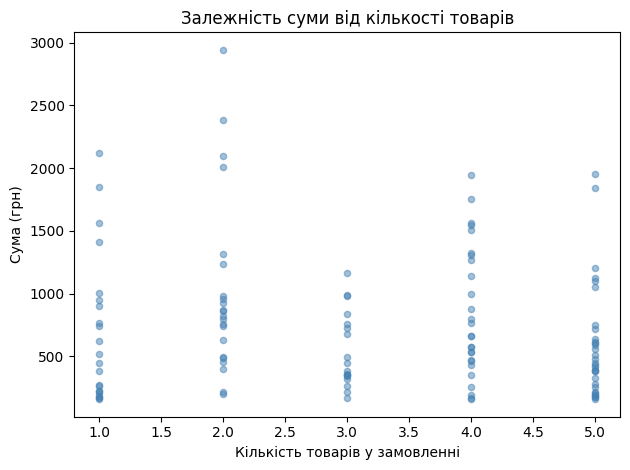

Кореляція: -0  (0 = нема зв'язку, 1 = прямий, -1 = зворотний)


In [35]:
# Чи є зв'язок між кількістю і сумою замовлення?
shop.plot.scatter(
    x='Кількість', y='Сума',
    alpha=0.5,
    color='steelblue',
    title="Залежність суми від кількості товарів",
    xlabel='Кількість товарів у замовленні',
    ylabel='Сума (грн)'
)
plt.tight_layout()
plt.show()

corr = shop['Кількість'].corr(shop['Сума'])
print(f"Кореляція: {corr:.0f}  (0 = нема зв'язку, 1 = прямий, -1 = зворотний)")

### 🎯 Завдання 3.1

На датасеті `shop`:
1. Додай стовпець `'Виручка_на_одиницю'` = Сума / Кількість (округли до цілих)
2. Додай стовпець `'VIP'`: True якщо сума > 1500, інакше False
3. Виведи scatter plot: вісь X = Кількість, вісь Y = Виручка_на_одиницю. Чи є закономірність?

In [36]:
# Твій код тут:


In [37]:
# 💡 Підказка:
print("""
s2 = shop.copy()
s2['Виручка_на_одиницю'] = (s2['Сума'] / s2['Кількість']).round(0).astype(int)
s2['VIP'] = s2['Сума'] > 1500

print(s2[['Сума','Кількість','Виручка_на_одиницю','VIP']].head(8))
print('VIP замовлень:', s2['VIP'].sum())

s2.plot.scatter(x='Кількість', y='Виручка_на_одиницю',
                alpha=0.5, color='purple',
                title='Виручка на одиницю vs Кількість')
plt.tight_layout()
plt.show()
""")


s2 = shop.copy()
s2['Виручка_на_одиницю'] = (s2['Сума'] / s2['Кількість']).round(0).astype(int)
s2['VIP'] = s2['Сума'] > 1500

print(s2[['Сума','Кількість','Виручка_на_одиницю','VIP']].head(8))
print('VIP замовлень:', s2['VIP'].sum())

s2.plot.scatter(x='Кількість', y='Виручка_на_одиницю',
                alpha=0.5, color='purple',
                title='Виручка на одиницю vs Кількість')
plt.tight_layout()
plt.show()



---
## Розділ 4 — Групування: groupby

`groupby` — це аналог зведеної таблиці в Excel.
Логіка завжди одна:

```python
df.groupby('поле_групування')['поле_значень'].функція()
#      ↑                            ↑               ↑
#  по чому групуємо          що рахуємо    sum/mean/max/count
```

In [38]:
# Загальна виручка по категоріях
by_category = shop.groupby('Категорія')['Сума'].sum().sort_values(ascending=False)
print(by_category)

Категорія
Одяг           29943
Електроніка    23671
Спорт          14451
Дім            12566
Книги           8060
Name: Сума, dtype: int64


In [39]:
# .agg() — кілька функцій одразу
# category_stats = shop.groupby('Категорія').agg(
#     Замовлень  = ('Сума', 'count'),
#     Сума_разом = ('Сума', 'sum'),
#     Сер_сума   = ('Сума', 'mean'),
#     Макс_сума  = ('Сума', 'max')
# ).round(0).astype(int)

category_stats = shop.groupby('Категорія')['Сума'].agg(['count', 'sum', 'min', 'max']).round(0).astype(int)

category_stats

,count,sum,min,max
Категорія,,,,
Дім,15,12566,194,2944
Електроніка,34,23671,157,1948
Книги,13,8060,194,1547
Одяг,38,29943,175,2384
Спорт,20,14451,159,2122


In [40]:
# Групування по двох полях + unstack = зведена таблиця
city_cat = shop.groupby(['Місто', 'Категорія'])['Сума'].sum().unstack(fill_value=0)
city_cat

Категорія,Дім,Електроніка,Книги,Одяг,Спорт
Місто,,,,,
Дніпро,2333,446,0,4899,1062
Київ,1814,7757,3998,10725,4902
Львів,3711,5581,1681,6038,1637
Одеса,4308,2213,1809,5934,4316
Харків,400,7674,572,2347,2534


### 📊 Bar chart після groupby — найчастіша комбінація

Результат `groupby` — це вже готові дані для графіка.

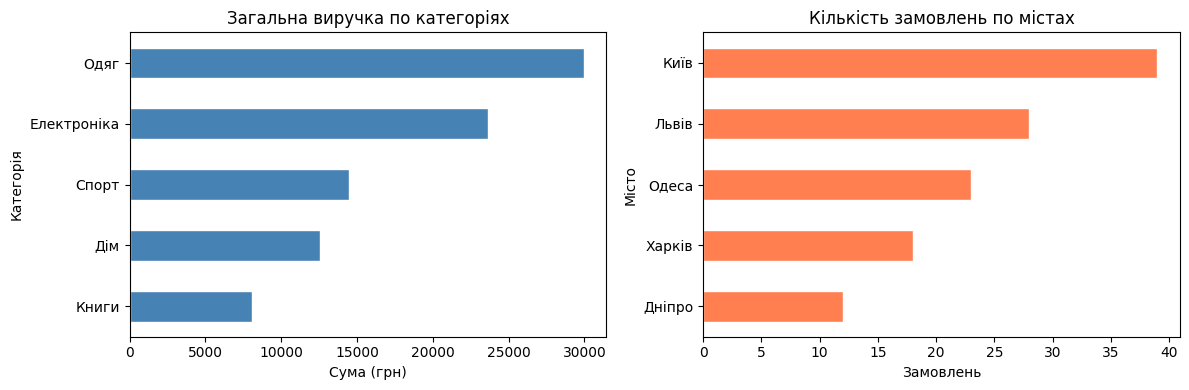

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Виручка по категоріях
by_cat = shop.groupby('Категорія')['Сума'].sum().sort_values()
by_cat.plot.barh(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Загальна виручка по категоріях')
axes[0].set_xlabel('Сума (грн)')

# Кількість замовлень по містах
by_city = shop.groupby('Місто')['Замовлення_ID'].count().sort_values()
by_city.plot.barh(ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Кількість замовлень по містах')
axes[1].set_xlabel('Замовлень')

plt.tight_layout()
plt.show()

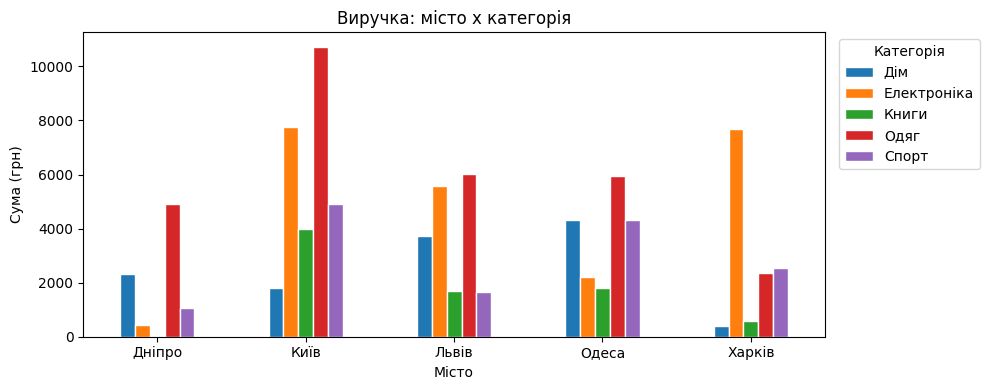

In [42]:
# Згрупований bar chart: кілька рядів даних
city_cat.plot.bar(
    figsize=(10, 4),
    edgecolor='white',
    title='Виручка: місто x категорія',
    ylabel='Сума (грн)',
    rot=0
)
plt.legend(title='Категорія', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 🎯 Завдання 4.1

Використовуючи `shop`:
1. Знайди середню суму замовлення по кожному місту (відсортуй від більшого)
2. Знайди кількість замовлень по кожному способу доставки
3. Побудуй **два** графіки на одному полотні: середня сума по містах і кількість по доставці

<Axes: title={'center': 'Середня сума по містах'}, xlabel='Доставка', ylabel='грн'>

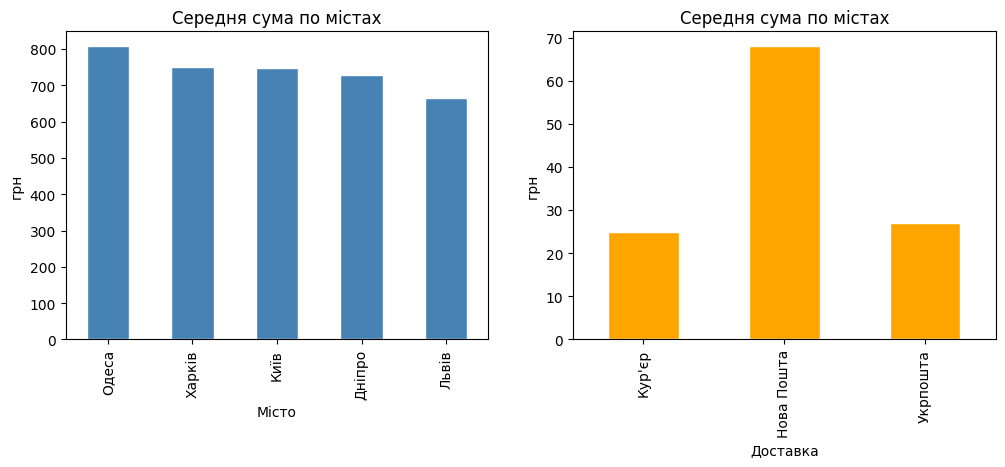

In [47]:
# Твій код тут:
avg_by_city = shop.groupby('Місто')['Сума'].mean().sort_values(ascending=False).round(1)
count_by_delivery_method = shop.groupby('Доставка')['Замовлення_ID'].count()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

avg_by_city.plot.bar(ax=ax[0], color='steelblue', edgecolor='white', title='Середня сума по містах', ylabel='грн')
count_by_delivery_method.plot.bar(ax=ax[1], color='orange', edgecolor='white', title='Середня сума по містах', ylabel='грн')









In [48]:
# 💡 Підказка:
print("""
avg_city     = shop.groupby('Місто')['Сума'].mean().sort_values(ascending=False).round(0)
delivery_cnt = shop.groupby('Доставка')['Замовлення_ID'].count()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

avg_city.plot.bar(ax=axes[0], color='steelblue', edgecolor='white', rot=30,
                  title='Середня сума по містах', ylabel='Грн')

delivery_cnt.plot.bar(ax=axes[1], color='mediumseagreen', edgecolor='white', rot=15,
                      title='Замовлень по доставці', ylabel='Кількість')

plt.tight_layout()
plt.show()
""")


avg_city     = shop.groupby('Місто')['Сума'].mean().sort_values(ascending=False).round(0)
delivery_cnt = shop.groupby('Доставка')['Замовлення_ID'].count()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

avg_city.plot.bar(ax=axes[0], color='steelblue', edgecolor='white', rot=30,
                  title='Середня сума по містах', ylabel='Грн')

delivery_cnt.plot.bar(ax=axes[1], color='mediumseagreen', edgecolor='white', rot=15,
                      title='Замовлень по доставці', ylabel='Кількість')

plt.tight_layout()
plt.show()



---
## Розділ 5 — Сортування та пошук топ-N

Часта задача аналітика: «хто в топ-5?», «що найгірше?», «відсортуй за двома полями».

In [51]:
print('Топ-5 найбільших замовлень:')
shop.sort_values('Сума', ascending=False)[['Замовлення_ID','Клієнт','Категорія','Сума']].head()

Топ-5 найбільших замовлень:


,Замовлення_ID,Клієнт,Категорія,Сума
90,1091,Тарас Н.,Дім,2944
5,1006,Тарас Н.,Одяг,2384
13,1014,Аня С.,Спорт,2122
66,1067,Богдан В.,Спорт,2099
24,1025,Богдан В.,Одяг,2009


In [52]:
# nlargest / nsmallest — зручний ярлик для топ-N
print('Топ-3 замовлення:')
print(shop.nlargest(3, 'Сума')[['Клієнт','Категорія','Місто','Сума']])

print()
print('3 найменших:')
print(shop.nsmallest(3, 'Сума')[['Клієнт','Категорія','Місто','Сума']])

Топ-3 замовлення:
      Клієнт Категорія  Місто  Сума
90  Тарас Н.       Дім  Львів  2944
5   Тарас Н.      Одяг  Одеса  2384
13    Аня С.     Спорт  Одеса  2122

3 найменших:
        Клієнт    Категорія   Місто  Сума
107  Богдан В.  Електроніка  Харків   157
32   Богдан В.        Спорт   Одеса   159
71   Максим Р.  Електроніка  Харків   161


In [53]:
# value_counts — підрахунок частоти кожного значення
print('Частота категорій:')
print(shop['Категорія'].value_counts())
print()
print('У відсотках:')
print((shop['Категорія'].value_counts(normalize=True) * 100).round(1))

Частота категорій:
Категорія
Одяг           38
Електроніка    34
Спорт          20
Дім            15
Книги          13
Name: count, dtype: int64

У відсотках:
Категорія
Одяг           31.7
Електроніка    28.3
Спорт          16.7
Дім            12.5
Книги          10.8
Name: proportion, dtype: float64


### 📊 Pie chart — частки від цілого

> 💡 **Коли pie, а коли bar?** Pie — якщо хочеш показати частки (~5 секцій максимум). Bar — якщо порівнюєш величини. Аналітики зазвичай надають перевагу bar — він точніший.

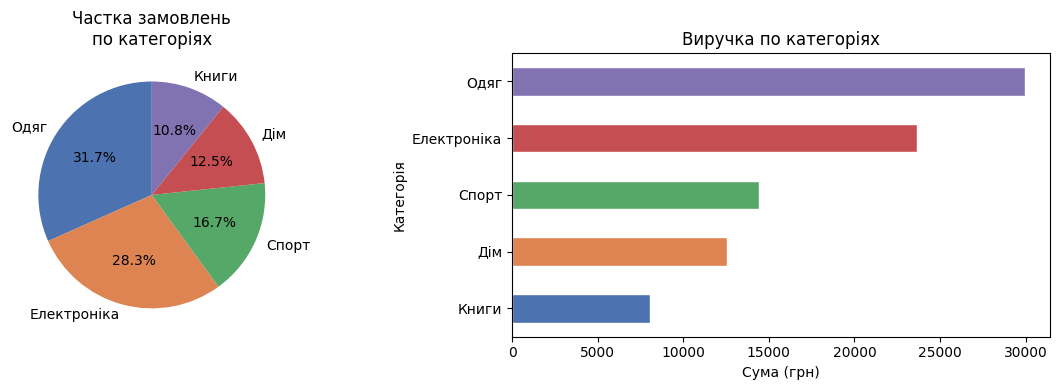

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Кругова діаграма
shop['Категорія'].value_counts().plot.pie(
    ax=axes[0],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2'],
    title='Частка замовлень\nпо категоріях'
)
axes[0].set_ylabel('')

# Bar — точніший для порівняння
shop.groupby('Категорія')['Сума'].sum().sort_values().plot.barh(
    ax=axes[1],
    color=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2'],
    edgecolor='white',
    title='Виручка по категоріях'
)
axes[1].set_xlabel('Сума (грн)')

plt.tight_layout()
plt.show()

### 🎯 Завдання 5.1

1. Знайди топ-3 клієнти за загальною сумою всіх їхніх замовлень
2. Порахуй кількість замовлень по кожному місту і відобрази у pie chart
3. Виведи 3 найменших замовлення з категорії «Книги»

In [ ]:
# Твій код тут:


In [ ]:
# 💡 Підказка:
print("""
top_clients = shop.groupby('Клієнт')['Сума'].sum().nlargest(3)
print(top_clients)

shop['Місто'].value_counts().plot.pie(
    autopct='%1.0f%%', startangle=90, title='Замовлення по містах'
)
plt.ylabel('')
plt.tight_layout()
plt.show()

books = shop[shop['Категорія'] == 'Книги']
print(books.nsmallest(3, 'Сума')[['Клієнт','Місто','Сума']])
""")

---
## Розділ 6 — Пропущені значення

Реальні дані завжди «брудні» — містять пропуски, помилки, дублікати.

`NaN` (Not a Number) — позначка пропущеного значення в pandas.

In [61]:
raw = pd.DataFrame({
    'Товар':     ['Ноутбук','Телефон','Планшет','Годинник','Навушники','Мишка','Клавіатура'],
    'Категорія': ['Техніка','Техніка', None,    'Аксесуари','Аксесуари', None, 'Аксесуари'],
    'Ціна':      [25000,    None,      9500,    4200,       None,        850,   1200],
    'Склад':     [12,       5,         None,    8,          20,          None,  15],
    'Рейтинг':   [4.5,      4.8,       4.2,     None,       4.6,         4.1,   None]
})

print('Дані:')
display(raw)
print('Пропуски по стовпцях:')
print(raw.isnull().sum())

Дані:


,Товар,Категорія,Ціна,Склад,Рейтинг
0,Ноутбук,Техніка,25000.0,12.0,4.5
1,Телефон,Техніка,NaN,5.0,4.8
2,Планшет,None,9500.0,NaN,4.2
3,Годинник,Аксесуари,4200.0,8.0,NaN
4,Навушники,Аксесуари,NaN,20.0,4.6
5,Мишка,None,850.0,NaN,4.1
6,Клавіатура,Аксесуари,1200.0,15.0,NaN


Пропуски по стовпцях:
Товар        0
Категорія    2
Ціна         2
Склад        2
Рейтинг      2
dtype: int64


In [62]:
clean = raw.copy()

# Числові → замінити середнім або медіаною
clean['Ціна']    = clean['Ціна'].fillna(clean['Ціна'].median())
clean['Склад']   = clean['Склад'].fillna(0)
clean['Рейтинг'] = clean['Рейтинг'].fillna(round(clean['Рейтинг'].mean(), 1))

# Текстові → замінити константою
clean['Категорія'] = clean['Категорія'].fillna('Невідомо')

print('Після очистки:')
display(clean)
print(f'Залишилось пропусків: {clean.isnull().sum().sum()}')

Після очистки:


,Товар,Категорія,Ціна,Склад,Рейтинг
0,Ноутбук,Техніка,25000.0,12.0,4.5
1,Телефон,Техніка,4200.0,5.0,4.8
2,Планшет,Невідомо,9500.0,0.0,4.2
3,Годинник,Аксесуари,4200.0,8.0,4.4
4,Навушники,Аксесуари,4200.0,20.0,4.6
5,Мишка,Невідомо,850.0,0.0,4.1
6,Клавіатура,Аксесуари,1200.0,15.0,4.4


Залишилось пропусків: 0


### 📊 Відсоток пропусків — візуалізуємо «брудність» даних

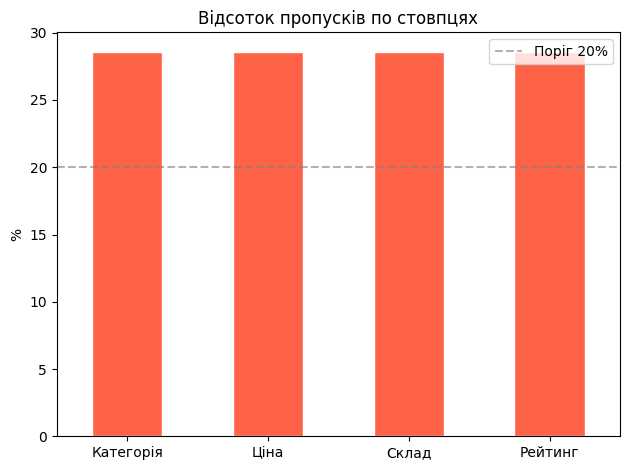

In [63]:
missing_pct = (raw.isnull().sum() / len(raw) * 100).round(1)
missing_pct_nz = missing_pct[missing_pct > 0]

missing_pct_nz.plot.bar(
    color='tomato', edgecolor='white', rot=0,
    title='Відсоток пропусків по стовпцях',
    ylabel='%'
)
plt.axhline(20, color='gray', linestyle='--', alpha=0.6, label='Поріг 20%')
plt.legend()
plt.tight_layout()
plt.show()

### 🎯 Завдання 6.1

Є дані моніторингу погоди зі станцій. Очисти датасет:
1. Виведи кількість і відсоток пропусків по кожному стовпцю
2. Заповни `Температура` медіаною, `Вітер_мс` — нулем, `Місто` — «Невідомо»
3. Побудуй bar chart відсотку пропусків **до** очистки

In [ ]:
stations = pd.DataFrame({
    'Станція':     ['S01','S02','S03','S04','S05','S06','S07','S08'],
    'Місто':       ['Київ', None, 'Харків', 'Одеса', None, 'Львів', 'Дніпро', None],
    'Температура': [-3, -5, None, 4, -1, None, 2, -2],
    'Вологість':   [72, 68, 75, 80, None, 65, None, 70],
    'Вітер_мс':    [5, None, 3, 8, 6, None, 4, 7]
})

print('До очистки:')
display(stations)

# Твій код тут:


In [ ]:
# 💡 Підказка:
print("""
missing = (stations.isnull().sum() / len(stations) * 100).round(1)
print(missing)

missing[missing > 0].plot.bar(color='tomato', edgecolor='white', rot=0,
                               title='Пропуски до очистки', ylabel='%')
plt.tight_layout()
plt.show()

st = stations.copy()
st['Температура'] = st['Температура'].fillna(st['Температура'].median())
st['Вітер_мс']    = st['Вітер_мс'].fillna(0)
st['Місто']       = st['Місто'].fillna('Невідомо')
display(st)
""")

---
## Розділ 7 — Часові ряди: дати в pandas

Дуже часто дані прив'язані до часу: продажі по днях, температура по годинах тощо.

In [ ]:
np.random.seed(7)
dates = pd.date_range(start='2024-01-01', end='2024-06-30', freq='D')

trend    = np.linspace(800, 1400, len(dates))
seasonal = 200 * np.sin(np.linspace(0, 4 * np.pi, len(dates)))
noise    = np.random.normal(0, 120, len(dates))
weekend  = np.array([300 if d.weekday() >= 5 else 0 for d in dates])

ts = pd.DataFrame({
    'Дата':    dates,
    'Продажі': (trend + seasonal + noise + weekend).clip(200).round(0).astype(int)
}).set_index('Дата')

print(f'Розмір: {ts.shape}')
ts.head(7)

In [ ]:
# Витягуємо частини дати
ts_ext = ts.copy()
ts_ext['Місяць']     = ts_ext.index.month
ts_ext['День_тижня'] = ts_ext.index.dayofweek  # 0=Пн, 6=Нд
ts_ext['Вихідний']   = ts_ext['День_тижня'] >= 5

ts_ext.head(8)

In [ ]:
# resample — агрегація по часовому вікну
# 'W' = тиждень, 'ME' = кінець місяця
weekly  = ts.resample('W')['Продажі'].sum()
monthly = ts.resample('ME')['Продажі'].sum()

print('По місяцях:')
print(monthly)

### 📊 Часовий ряд — лінійний графік

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7))

# Денні продажі + ковзне середнє
ts['Продажі'].plot(ax=axes[0], color='steelblue', alpha=0.6, linewidth=1)
ts['Продажі'].rolling(7).mean().plot(
    ax=axes[0], color='red', linewidth=2, label='7-денне середнє'
)
axes[0].set_title('Щоденні продажі + ковзне середнє')
axes[0].set_ylabel('Грн')
axes[0].legend()

# Місячна виручка
month_labels = ['Січень','Лютий','Березень','Квітень','Травень','Червень']
axes[1].bar(range(len(monthly)), monthly.values, color='steelblue', edgecolor='white')
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels(month_labels)
axes[1].set_title('Місячна виручка')
axes[1].set_ylabel('Грн')

plt.tight_layout()
plt.show()

In [ ]:
# Середні продажі по дню тижня
days_ua = ['Пн','Вт','Ср','Чт','Пт','Сб','Нд']
avg_by_weekday = ts_ext.groupby('День_тижня')['Продажі'].mean().round(0)

colors = ['#C44E52' if i >= 5 else 'steelblue' for i in range(7)]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(days_ua, avg_by_weekday.values, color=colors, edgecolor='white')
ax.set_title('Середні продажі по дню тижня')
ax.set_ylabel('Грн')

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 10,
            f'{h:,.0f}', ha='center', va='bottom', fontsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='steelblue', label='Будній'),
                   Patch(facecolor='#C44E52',   label='Вихідний')])
plt.tight_layout()
plt.show()

### 🎯 Завдання 7.1

Використовуючи `ts`:
1. Знайди день з максимальними та мінімальними продажами
2. Порахуй середні продажі по місяцях (`resample('ME').mean()`)
3. Побудуй лінійний графік місячних середніх

In [ ]:
# Твій код тут:


In [ ]:
# 💡 Підказка:
print("""
print('Максимум:', ts['Продажі'].idxmax(), ts['Продажі'].max())
print('Мінімум: ', ts['Продажі'].idxmin(), ts['Продажі'].min())

monthly_avg = ts.resample('ME')['Продажі'].mean().round(0)
print(monthly_avg)

monthly_avg.plot(kind='line', marker='o', color='steelblue', linewidth=2,
                 title='Середній денний продаж по місяцях', ylabel='Грн')
plt.tight_layout()
plt.show()
""")

---
## 🏆 Фінальний проєкт — Аналітичний звіт

Ти — junior аналітик даних в інтернет-магазині.
Керівник просить підготувати **щомісячний звіт** за першу половину 2024 року.

In [64]:
# Генерація фінального датасету
np.random.seed(2024)
N = 500

dates_full  = pd.date_range('2024-01-01', '2024-06-30', freq='D')
order_dates = np.random.choice(dates_full, N)

final = pd.DataFrame({
    'Дата':       pd.to_datetime(order_dates),
    'Клієнт_ID':  np.random.randint(1001, 1200, N),
    'Категорія':  np.random.choice(['Електроніка','Одяг','Книги','Спорт','Дім'], N,
                                    p=[0.22,0.28,0.18,0.17,0.15]),
    'Місто':      np.random.choice(['Київ','Харків','Одеса','Львів','Дніпро'], N,
                                    p=[0.35,0.20,0.15,0.20,0.10]),
    'Сума':       (np.random.exponential(700, N) + 200).round(0).astype(int),
    'Кількість':  np.random.randint(1, 7, N),
    'Знижка_%':   np.random.choice([0,5,10,15,20], N, p=[0.45,0.25,0.15,0.10,0.05]),
    'Повернення': np.random.choice([False, True], N, p=[0.92, 0.08])
})

final['Місяць']       = final['Дата'].dt.month
final['Місяць_назва'] = final['Дата'].dt.strftime('%b')
final['Вихідний']     = final['Дата'].dt.dayofweek >= 5
final['Сума_чиста']   = (final['Сума'] * (1 - final['Знижка_%'] / 100)).round(0).astype(int)

print(f'Датасет: {final.shape[0]} замовлень')
print(f'Загальна виручка: {final["Сума_чиста"].sum():,} грн')
print(f'Середній чек:     {final["Сума_чиста"].mean():.0f} грн')
print(f'Повернень:        {final["Повернення"].sum()} ({final["Повернення"].mean()*100:.1f}%)')
final.head(6)

Датасет: 500 замовлень
Загальна виручка: 421,449 грн
Середній чек:     843 грн
Повернень:        36 (7.2%)


,Дата,Клієнт_ID,Категорія,Місто,Сума,Кількість,Знижка_%,Повернення,Місяць,Місяць_назва,Вихідний,Сума_чиста
0,2024-05-16,1047,Одяг,Харків,209,3,0,False,5,May,False,209
1,2024-04-06,1105,Книги,Львів,573,4,0,False,4,Apr,True,573
2,2024-05-08,1150,Електроніка,Харків,1281,6,0,False,5,May,False,1281
3,2024-01-28,1034,Книги,Київ,1416,4,5,False,1,Jan,True,1345
4,2024-02-06,1054,Одяг,Дніпро,388,3,10,False,2,Feb,False,349
5,2024-02-11,1172,Електроніка,Київ,293,2,20,False,2,Feb,True,234


### 🎯 Фінальне завдання — Дашборд

Підготуй звіт із таких блоків:

**Блок A — Динаміка продажів**
- Загальна виручка по місяцях
- Виручка у вихідні vs будні

**Блок B — Структура продажів**
- Виручка по категоріях (barh)
- Кількість замовлень по містах (bar)

**Блок C — Аналіз клієнтів**
- Розподіл сум замовлень (histogram)
- Топ-5 клієнтів за загальною сумою (barh)

**Блок D — Текстові висновки:** який місяць найкращий? яка категорія? місто-лідер?

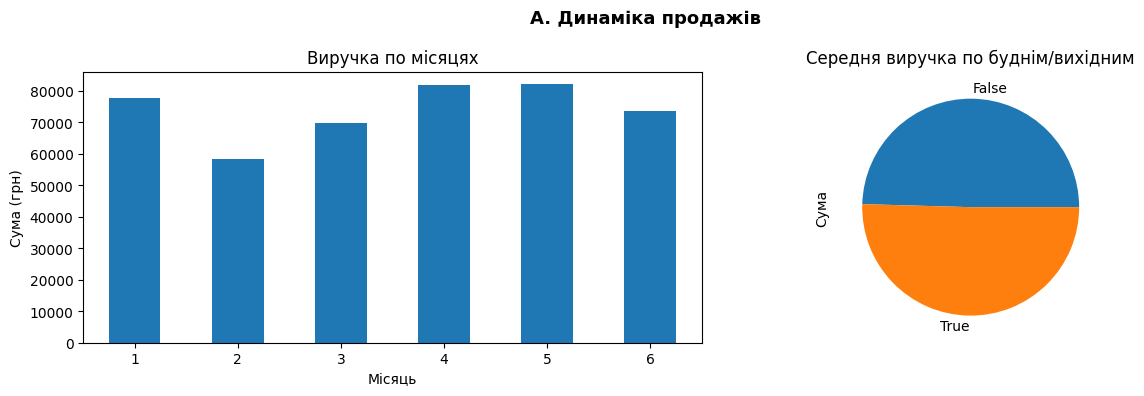

In [67]:
# ═══ БЛОК A — Динаміка продажів ═══
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('A. Динаміка продажів', fontsize=13, weight='bold')

# Твій код тут:
rev_by_month = final.groupby('Місяць')['Сума'].sum()
rev_by_month.plot.bar(ax=axes[0], title='Виручка по місяцях', ylabel='Сума (грн)', rot=0)

rev_by_weekday = final.groupby('Вихідний')['Сума'].mean()
rev_by_weekday.plot.pie(ax=axes[1], title='Середня виручка по буднім/вихідним')
# avg_by_city.plot.bar(ax=ax[0], color='steelblue', edgecolor='white', title='Середня сума по містах', ylabel='грн')

plt.tight_layout()
plt.show()

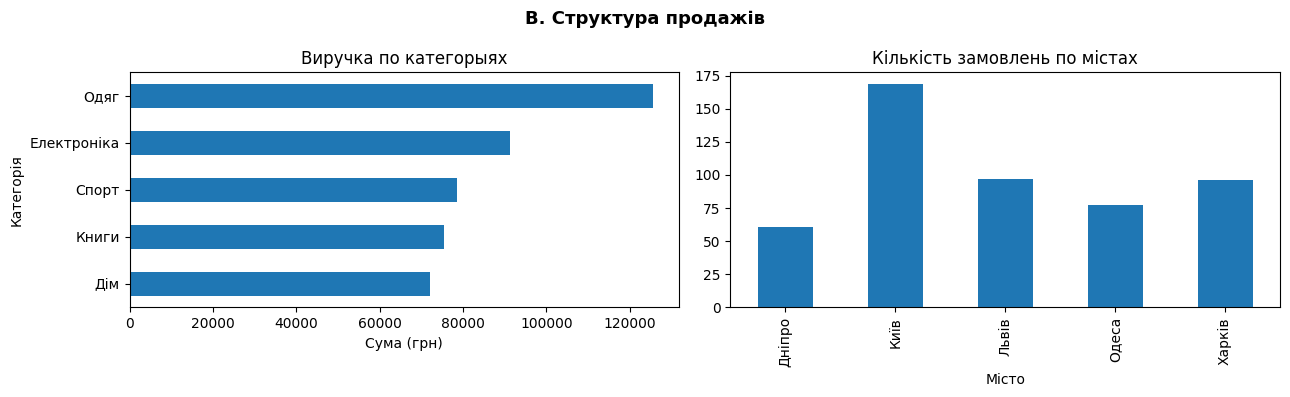

In [74]:
# ═══ БЛОК B — Структура ═══
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('B. Структура продажів', fontsize=13, weight='bold')

# Твій код тут:
rev_by_category = final.groupby('Категорія')['Сума'].sum().sort_values()
rev_by_category.plot.barh(ax=axes[0], title='Виручка по категорыях', xlabel='Сума (грн)')

count_by_city = final.groupby('Місто')['Клієнт_ID'].count()
count_by_city.plot.bar(ax=axes[1], title='Кількість замовлень по містах')

plt.tight_layout()
plt.show()

In [ ]:
# ═══ БЛОК C — Клієнти ═══
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('C. Аналіз клієнтів', fontsize=13, weight='bold')

# Твій код тут:

plt.tight_layout()
plt.show()

### D. Висновки

*(Напиши тут свої висновки після аналізу)*

- **Найкращий місяць:** ...
- **Найприбутковіша категорія:** ...
- **Місто-лідер:** ...
- **Рекомендації:** ...

In [ ]:
# 💡 Підказка до фінального проєкту:
print("""
# ═══ БЛОК A ═══
month_names = ['Січ','Лют','Бер','Кві','Тра','Чер']
monthly_rev = final.groupby('Місяць')['Сума_чиста'].sum()
axes[0].bar(month_names[:len(monthly_rev)], monthly_rev.values,
            color='steelblue', edgecolor='white')
axes[0].set_title('Виручка по місяцях')
axes[0].set_ylabel('Грн')

weekend_rev = final.groupby('Вихідний')['Сума_чиста'].sum()
axes[1].bar(['Будні','Вихідні'], weekend_rev.values,
            color=['steelblue','#C44E52'], edgecolor='white')
axes[1].set_title('Виручка: будні vs вихідні')

# ═══ БЛОК B ═══
cat_rev = final.groupby('Категорія')['Сума_чиста'].sum().sort_values()
cat_rev.plot.barh(ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Виручка по категоріях')

city_cnt = final['Місто'].value_counts()
city_cnt.plot.bar(ax=axes[1], color='mediumseagreen', edgecolor='white', rot=20)
axes[1].set_title('Замовлень по містах')

# ═══ БЛОК C ═══
final['Сума_чиста'].plot.hist(ax=axes[0], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(final['Сума_чиста'].mean(), color='red', linestyle='--',
                label=f"Середнє: {final['Сума_чиста'].mean():.0f}")
axes[0].set_title('Розподіл сум замовлень')
axes[0].legend()

top5 = final.groupby('Клієнт_ID')['Сума_чиста'].sum().nlargest(5)
top5.plot.barh(ax=axes[1], color='#8172B2', edgecolor='white')
axes[1].set_title('Топ-5 клієнтів')

# ═══ ВИСНОВКИ ═══
print('Найкращий місяць:         ', final.groupby('Місяць')['Сума_чиста'].sum().idxmax())
print('Найприбутковіша категорія:', final.groupby('Категорія')['Сума_чиста'].sum().idxmax())
print('Місто-лідер:              ', final['Місто'].value_counts().idxmax())
""")

---
## 📋 Шпаргалка — Pandas + Matplotlib разом

### Основні операції Pandas

| Що зробити | Код |
|-----------|-----|
| Створити таблицю | `pd.DataFrame({'col': [1,2,3]})` |
| Розмір | `df.shape` |
| Перші рядки | `df.head(5)` |
| Статистика | `df.describe()` |
| Вибрати стовпець | `df['col']` |
| Вибрати кілька | `df[['col1','col2']]` |
| Фільтр | `df[df['col'] > 5]` |
| Складний фільтр | `df[(df['a'] > 1) & (df['b'] == 'X')]` |
| Новий стовпець | `df['new'] = df['a'] * 2` |
| Умовний стовпець | `np.where(умова, якщо_так, якщо_ні)` |
| Групування | `df.groupby('col')['val'].sum()` |
| Сортування | `df.sort_values('col', ascending=False)` |
| Топ-N | `df.nlargest(5, 'col')` |
| Частота | `df['col'].value_counts()` |
| Пропуски | `df.isnull().sum()` |
| Заповнити NaN | `df['col'].fillna(0)` |
| Ресемплінг | `df.resample('ME').sum()` |

### Типи графіків і коли їх використовувати

| Тип | Код | Коли |
|-----|-----|------|
| Лінійний | `.plot(kind='line')` | Динаміка в часі |
| Стовпці | `.plot(kind='bar')` | Порівняння категорій |
| Горизонт. | `.plot(kind='barh')` | Рейтинги, довгі підписи |
| Кругова | `.plot(kind='pie')` | Частки (до ~5 секцій) |
| Гістограма | `.plot(kind='hist')` | Розподіл числових даних |
| Scatter | `.plot(kind='scatter', x=, y=)` | Зв'язок двох змінних |
| Кілька | `fig, axes = plt.subplots(r, c)` | Дашборд |

### Формула: groupby → графік
```python
result = df.groupby('категорія')['значення'].sum()  # 1. рахуємо
result.plot.bar(title='...', ylabel='...', edgecolor='white')  # 2. малюємо
plt.tight_layout()
plt.show()
```

---
## Що далі?
- **Seaborn** — красивіша статистична візуалізація
- **Pandas advanced** — `merge`, `pivot_table`, `apply`
- **Plotly** — інтерактивні графіки
- **Scikit-learn** — машинне навчання